<a href="https://colab.research.google.com/github/swathivenkatesan87/24ADI003-24BAD122-ML/blob/main/exp_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# NAME: SWATHI
# ROLL NO: 24BAD122
# EXPT NO: 6

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


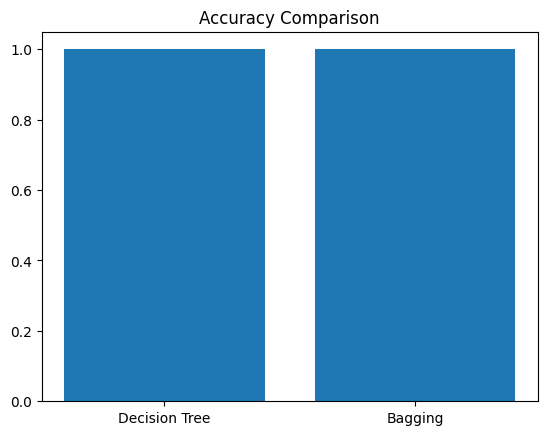

Confusion Matrix (Bagging):
[[ 6  0]
 [ 0 18]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# Load dataset
data = pd.read_csv("diabetes_bagging.csv")

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

# Bar Graph
models = ["Decision Tree", "Bagging"]
accuracy = [acc_dt, acc_bag]

plt.bar(models, accuracy)
plt.title("Accuracy Comparison")
plt.show()

# Confusion Matrix
print("Confusion Matrix (Bagging):")
print(confusion_matrix(y_test, y_pred_bag))

Confusion Matrix:
 [[ 6  0]
 [ 0 18]]


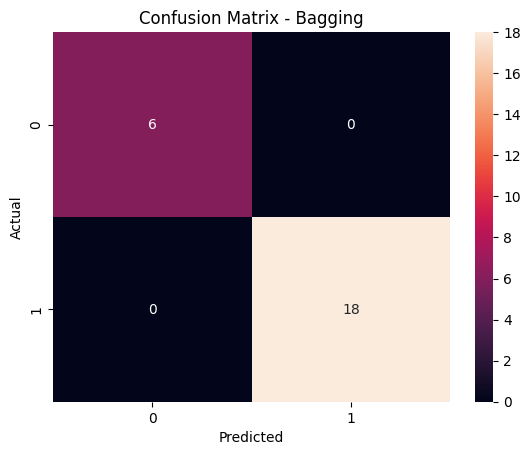

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_bag)

print("Confusion Matrix:\n", cm)

# Plot Confusion Matrix
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Bagging")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

AdaBoost Accuracy: 1.0
Gradient Boosting Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


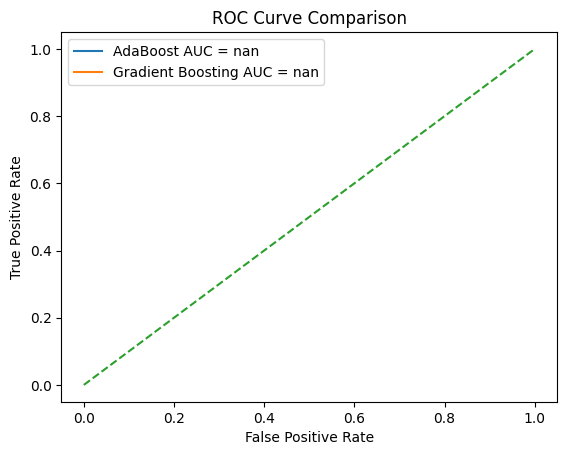

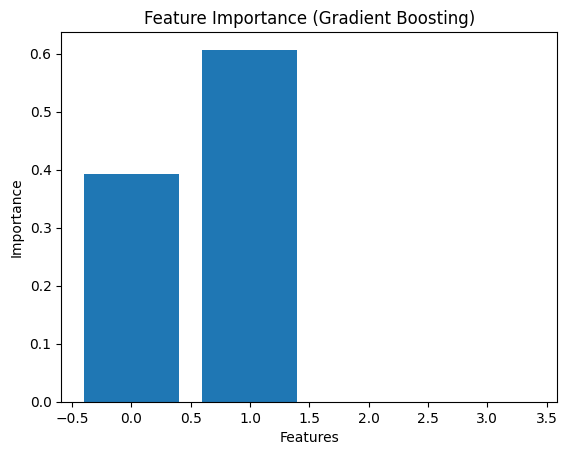

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_curve, auc

# Load dataset
data = pd.read_csv("churn_boosting.csv")

# Encoding categorical columns
le = LabelEncoder()
for col in data.select_dtypes(include=['object']):
    data[col] = le.fit_transform(data[col])

# Features & Target
X = data.drop("Churn", axis=1)
y = data["Churn"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# AdaBoost
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# Accuracy
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

# ROC Curve (Improved)
y_prob_ada = ada.predict_proba(X_test)[:, 1]
y_prob_gb = gb.predict_proba(X_test)[:, 1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_ada = auc(fpr_ada, tpr_ada)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure()
plt.plot(fpr_ada, tpr_ada, label="AdaBoost AUC = %0.2f" % auc_ada)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting AUC = %0.2f" % auc_gb)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Feature Importance (GB)
plt.figure()
plt.bar(range(len(gb.feature_importances_)), gb.feature_importances_)
plt.title("Feature Importance (Gradient Boosting)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

Columns: Index(['Amount', 'Time', 'Feature1', 'Feature2', 'Fraud'], dtype='object')
Using target column: Fraud
10 Trees Accuracy: 0.9166666666666666
50 Trees Accuracy: 0.9166666666666666
100 Trees Accuracy: 0.9166666666666666


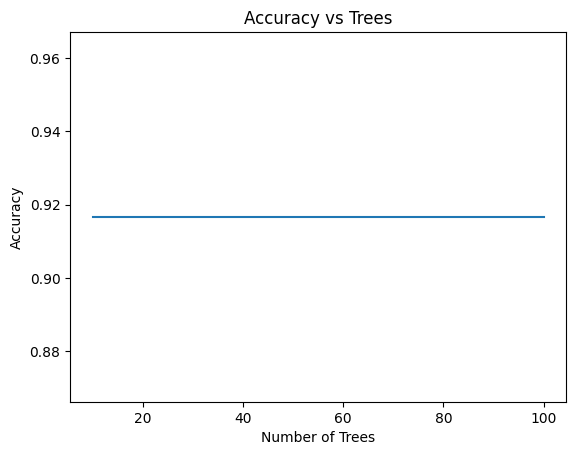


Final Accuracy: 0.9166666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


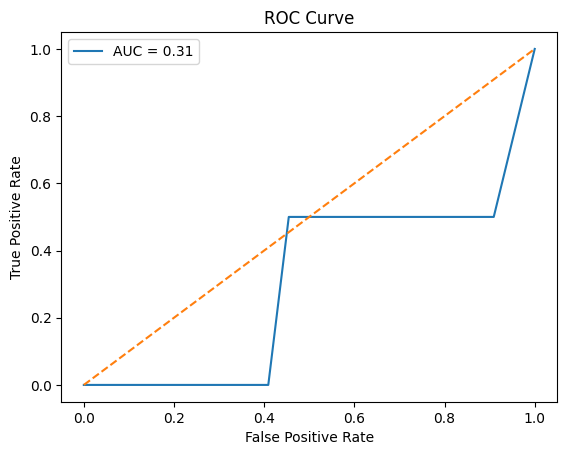

In [ ]:
# NAME: SWATHI
# ROLL NO: 24BAD122
# EXPT NO: 6

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc

# Load dataset
data = pd.read_csv("fraud_smote.csv")

# Check columns
print("Columns:", data.columns)

# AUTO DETECT TARGET COLUMN
if 'Class' in data.columns:
    target = 'Class'
elif 'Fraud' in data.columns:
    target = 'Fraud'
elif 'target' in data.columns:
    target = 'target'
elif 'label' in data.columns:
    target = 'label'
else:
    raise Exception("Target column not found. Check dataset!")

print("Using target column:", target)

# Features & Target
X = data.drop(target, axis=1)
y = data[target]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Accuracy vs Number of Trees
trees = [10, 50, 100]
acc = []

for n in trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)

    score = accuracy_score(y_test, pred)
    acc.append(score)

    print(f"{n} Trees Accuracy:", score)

# Graph
plt.figure()
plt.plot(trees, acc)
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Trees")
plt.show()
# Final Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("\nFinal Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC Curve

# Get probability scores
y_prob = rf.predict_proba(X_test)[:, 1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Columns: Index(['Age', 'Cholesterol', 'MaxHeartRate', 'RestingBP', 'HeartDisease'], dtype='object')
Using target column: HeartDisease
lr Accuracy: 0.8333333333333334
svm Accuracy: 0.8333333333333334
dt Accuracy: 0.9583333333333334
Stacking Accuracy: 0.9583333333333334


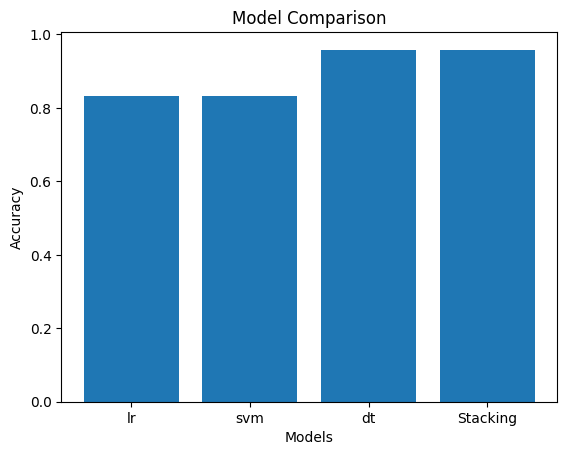

In [ ]:
# NAME: SWATHI
# ROLL NO: 24BAD122
# EXPT NO: 6

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

#  Load dataset
data = pd.read_csv("heart.csv")

#  Check columns
print("Columns:", data.columns)

#  AUTO DETECT TARGET COLUMN
if 'target' in data.columns:
    target = 'target'
elif 'output' in data.columns:
    target = 'output'
elif 'HeartDisease' in data.columns:
    target = 'HeartDisease'
elif 'num' in data.columns:
    target = 'num'
elif 'label' in data.columns:
    target = 'label'
else:
    raise Exception(" Target column not found. Check dataset!")

print("Using target column:", target)

#  Features & Target
X = data.drop(target, axis=1)
y = data[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Base models
models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

#  Stacking model
stack = StackingClassifier(
    estimators=models,
    final_estimator=LogisticRegression()
)

# Train stacking
stack.fit(X_train, y_train)

#  Compare models
scores = []
labels = []

for name, model in models:
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    scores.append(acc)
    labels.append(name)
    print(name, "Accuracy:", acc)

# Stacking
stack_acc = accuracy_score(y_test, stack.predict(X_test))
scores.append(stack_acc)
labels.append("Stacking")

print("Stacking Accuracy:", stack_acc)

# Graph
plt.bar(labels, scores)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()


Before SMOTE:
Income
0    80
1    40
Name: count, dtype: int64


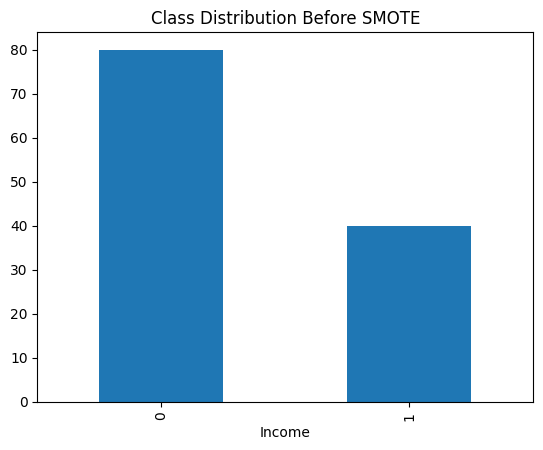


--- BEFORE SMOTE ---
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         8

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


After SMOTE:
Income
1    64
0    64
Name: count, dtype: int64


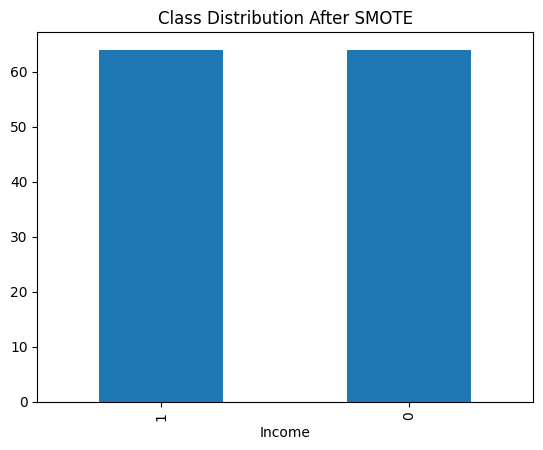


--- AFTER SMOTE ---
Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.89      1.00      0.94         8

    accuracy                           0.96        24
   macro avg       0.94      0.97      0.95        24
weighted avg       0.96      0.96      0.96        24



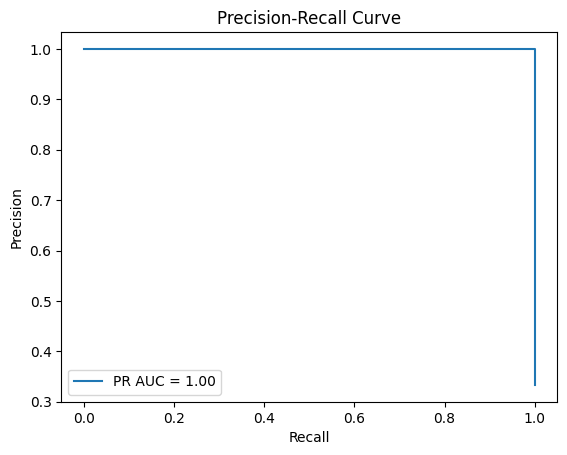

In [ ]:
# NAME: SWATHI
# ROLL NO: 24BAD122
# EXPT NO: 6

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_recall_curve, average_precision_score

from imblearn.over_sampling import SMOTE

# Load dataset
data = pd.read_csv("income_random_forest.csv")

# Features & Target
X = data.drop("Income", axis=1)
y = data["Income"]

# Before SMOTE
print("\nBefore SMOTE:")
print(y.value_counts())

plt.figure()
y.value_counts().plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.show()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model BEFORE SMOTE
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_before = model.predict(X_test)

print("\n--- BEFORE SMOTE ---")
print("Accuracy:", accuracy_score(y_test, y_pred_before))
print(classification_report(y_test, y_pred_before))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# After SMOTE
print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

plt.figure()
pd.Series(y_train_sm).value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.show()

# Model AFTER SMOTE
model_sm = LogisticRegression(max_iter=1000)
model_sm.fit(X_train_sm, y_train_sm)

y_pred_after = model_sm.predict(X_test)

print("\n--- AFTER SMOTE ---")
print("Accuracy:", accuracy_score(y_test, y_pred_after))
print(classification_report(y_test, y_pred_after))

# Precision-Recall Curve
y_scores = model_sm.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
pr_auc = average_precision_score(y_test, y_scores)

plt.figure()
plt.plot(recall, precision, label="PR AUC = %0.2f" % pr_auc)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()